In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Now, let's list the contents of the 'RPPB' folder within 'datasets'
# Please ensure 'RPPB' is the correct folder name as listed above.
import os
rppb_path = '/content/drive/MyDrive/datasets/RPPB/'

if os.path.exists(rppb_path):
    print(f"\nContents of '{rppb_path}':")
    for item in os.listdir(rppb_path):
        print(item)
else:
    print(f"The folder '{rppb_path}' does not exist. Please check the folder name and path.")



Contents of '/content/drive/MyDrive/datasets/RPPB/':
frame_000.jpg
frame_004.jpg


In [8]:
# Instalamos la librería
!pip install ultralytics

import os
from ultralytics import YOLO
print("Librería instalada y cargada correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Librería instalada y cargada correctamente.


```markdown
### Prueba de detección rápida
Ahora que el modelo está cargado con la configuración de COCO, podemos probarlo con una imagen de ejemplo.
```

In [9]:
from ultralytics import YOLO

# 1. Primero cargamos el modelo pre-entrenado (esto crea la variable 'model')
model = YOLO('yolov8n.pt')

# 2. Ahora sí podemos realizar la inferencia
results = model.predict('https://ultralytics.com/images/bus.jpg', save=True)

# 3. Mostrar los resultados de los objetos detectados
for r in results:
    print(f"Se han detectado {len(r.boxes)} objetos en la imagen.")


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 910.9ms
Speed: 30.0ms preprocess, 910.9ms inference, 57.2ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Se han detectado 6 objetos en la imagen.


In [10]:
results = model.predict('/content/drive/MyDrive/datasets/RPPB/frame_000.jpg', save = True)



image 1/1 /content/drive/MyDrive/datasets/RPPB/frame_000.jpg: 480x640 1 sports ball, 257.8ms
Speed: 1.9ms preprocess, 257.8ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


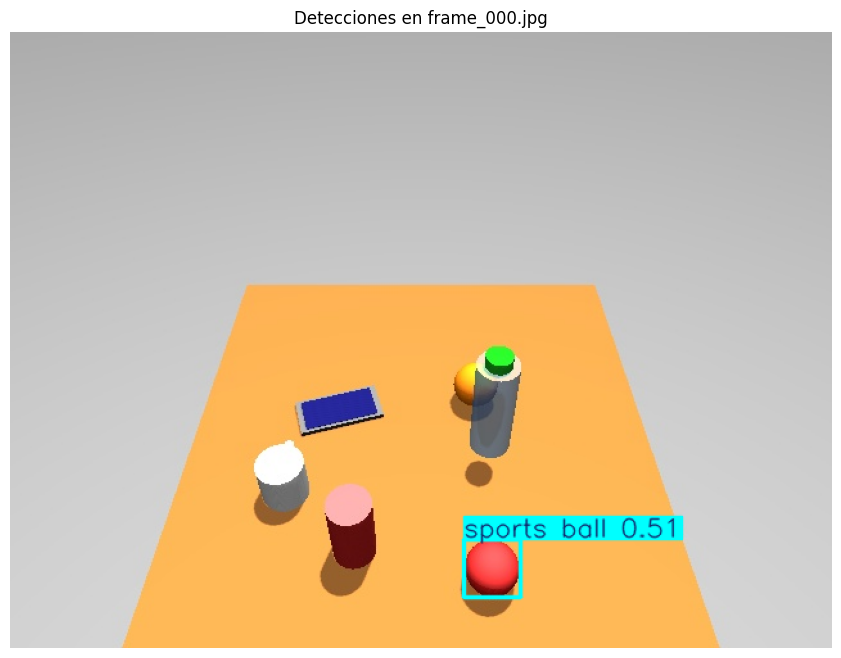

In [11]:
import matplotlib.pyplot as plt

# Usamos el objeto 'results' que ya tenemos en memoria de la celda anterior
# .plot() dibuja automáticamente los recuadros y etiquetas
res_plotted = results[0].plot()

# Convertimos de BGR (OpenCV) a RGB (Matplotlib)
res_rgb = res_plotted[:, :, ::-1]

plt.figure(figsize=(12, 8))
plt.imshow(res_rgb)
plt.axis('off')
plt.title("Detecciones en frame_000.jpg")
plt.show()

# Si quieres intentar detectar más cosas, podemos bajar el umbral de confianza:
# results = model.predict('/content/drive/MyDrive/datasets/RPPB/frame_000.jpg', conf=0.15)


image 1/1 /content/drive/MyDrive/datasets/RPPB/frame_000.jpg: 480x640 1 sports ball, 1 bottle, 2 cups, 2 oranges, 1 book, 3628.3ms
Speed: 3.8ms preprocess, 3628.3ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict-2


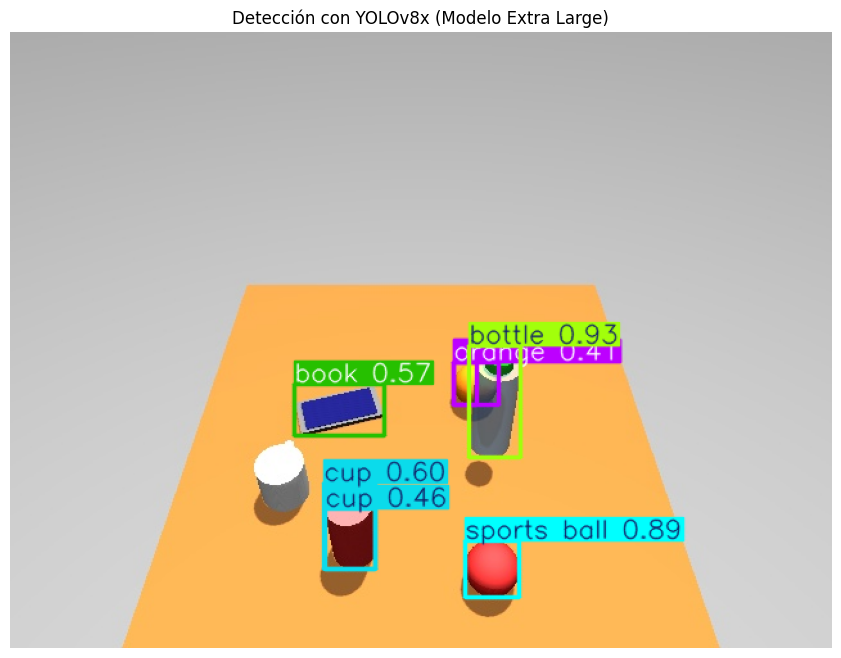

In [12]:
# Cargamos la versión 'Extra Large' de YOLOv8 para máxima precisión
model_xl = YOLO('yolov8x.pt')

# Ejecutamos la predicción en la misma imagen
results_xl = model_xl.predict('/content/drive/MyDrive/datasets/RPPB/frame_000.jpg', save=True)

# Visualizamos los resultados del modelo potente
res_plotted_xl = results_xl[0].plot()
res_rgb_xl = res_plotted_xl[:, :, ::-1]

plt.figure(figsize=(12, 8))
plt.imshow(res_rgb_xl)
plt.axis('off')
plt.title("Detección con YOLOv8x (Modelo Extra Large)")
plt.show()

```markdown
### Afinando la detección con Hi-Res y Ajuste de Confianza

Podemos forzar al modelo a mirar con más detalle aumentando el parámetro `imgsz` (por defecto es 640) y ajustando la confianza.
```


image 1/1 /content/drive/MyDrive/datasets/RPPB/frame_000.jpg: 608x800 2 sports balls, 1 bottle, 1 cup, 1 book, 6258.7ms
Speed: 6.0ms preprocess, 6258.7ms inference, 1.4ms postprocess per image at shape (1, 3, 608, 800)
Results saved to /content/runs/detect/predict-2


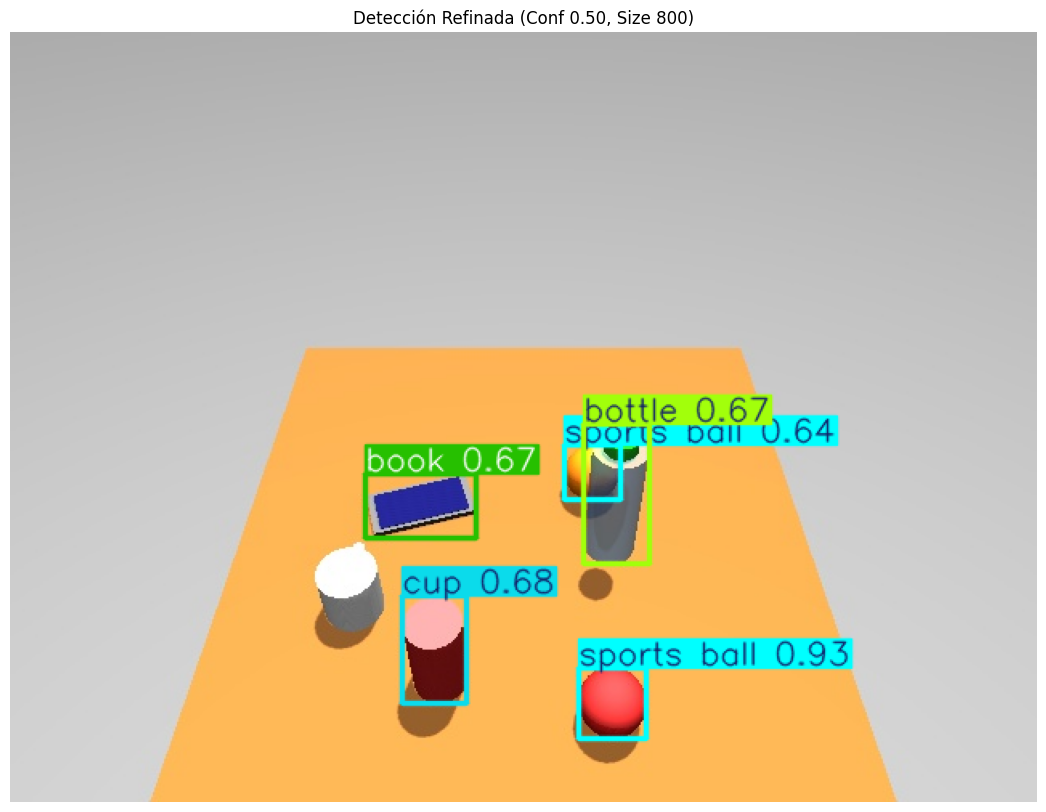

In [13]:
# Ejecutamos con mayor resolución (800px) y un umbral de confianza de 0.5
results_refined = model_xl.predict(
    source='/content/drive/MyDrive/datasets/RPPB/frame_000.jpg',
    conf=0.50,   # Umbral ajustado a 0.5 para filtrar detecciones dudosas
    imgsz=800,   # Mayor resolución para objetos pequeños
    save=True
)

# Visualización
res_plotted_ref = results_refined[0].plot()
plt.figure(figsize=(15, 10))
plt.imshow(res_plotted_ref[:, :, ::-1])
plt.axis('off')
plt.title("Detección Refinada (Conf 0.50, Size 800)")
plt.show()